In [2]:
import importlib
import numpy as np
import polars as pl
import scipy.sparse as sp
import torch
import torch.nn as nn
from tqdm import tqdm

from datasets import DATA_FOLDER, Dataloader, prepare_interaction_data, split_input_target_interactions
from util import CHECKPOINT_FOLDER, get_checkpoint_filepath, load_checkpoint, load_config_from_checkpoint, set_seed

# device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
device = torch.device("cpu")

DATASET = "ML-25M"
ELSA_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/TopKSAE-8192-d6337b64.ckpt"  # ELSA + L2
MULTVAE_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/TopKSAE-8192-f634db83.ckpt"  # MultVAE + L2

elsa_sae_cfg = load_config_from_checkpoint(ELSA_CHECKPOINT_PATH)
elsa_checkpoint_path = f"{CHECKPOINT_FOLDER}/{DATASET}/{elsa_sae_cfg['pretrained_model_checkpoint']}"
elsa_cfg = load_config_from_checkpoint(elsa_checkpoint_path)
multvae_sae_cfg = load_config_from_checkpoint(MULTVAE_CHECKPOINT_PATH)
multvae_checkpoint_path = f"{CHECKPOINT_FOLDER}/{DATASET}/{multvae_sae_cfg['pretrained_model_checkpoint']}"
multvae_cfg = load_config_from_checkpoint(multvae_checkpoint_path)

set_seed(elsa_cfg["seed"])

interactions_df, train_csr, val_csr, test_csr, train_users, val_users, test_users, items = prepare_interaction_data(
    elsa_cfg
)  # both models use the same dataset configuration
train_users_to_idxs = {uid: uidx for uidx, uid in enumerate(train_users)}
val_users_to_idxs = {uid: uidx for uidx, uid in enumerate(val_users)}
test_users_to_idxs = {uid: uidx for uidx, uid in enumerate(test_users)}
items_to_idxs = {iid: iidx for iidx, iid in enumerate(items)}

items_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/movies.csv").rename({"movieId": "item_id"}).cast({"item_id": pl.String}).cast({"item_id": pl.Categorical}).collect()
)

elsa_model_class = getattr(importlib.import_module(elsa_cfg["model_module"]), elsa_cfg["model_class"])
elsa_model = elsa_model_class(train_csr.shape[1], elsa_cfg["embedding_dim"]).to(device)
multvae_model_class = getattr(importlib.import_module(multvae_cfg["model_module"]), multvae_cfg["model_class"])
multvae_model = multvae_model_class(
    train_csr.shape[1],
    [int(x) for x in multvae_cfg["hidden_dims"].split(",") if x.strip()],
    multvae_cfg["embedding_dim"],
    multvae_cfg["annealing_beta"],
    multvae_cfg["annealing_steps"],
).to(device)
_, _ = load_checkpoint(elsa_model, None, get_checkpoint_filepath(elsa_cfg), device, None)
_, _ = load_checkpoint(multvae_model, None, get_checkpoint_filepath(multvae_cfg), device, None)

elsa_sae_model_class = getattr(importlib.import_module(elsa_sae_cfg["model_module"]), elsa_sae_cfg["model_class"])
elsa_sae = elsa_sae_model_class(
    elsa_cfg["embedding_dim"],
    elsa_sae_cfg["embedding_dim"],
    elsa_sae_cfg["reconstruction_loss"],
    l1_coef=elsa_sae_cfg["l1_coef"],
    k=elsa_sae_cfg["k"],
).to(device)
multvae_sae_model_class = getattr(importlib.import_module(multvae_sae_cfg["model_module"]), multvae_sae_cfg["model_class"])
multvae_sae = multvae_sae_model_class(
    multvae_cfg["embedding_dim"],
    multvae_sae_cfg["embedding_dim"],
    multvae_sae_cfg["reconstruction_loss"],
    l1_coef=multvae_sae_cfg["l1_coef"],
    k=multvae_sae_cfg["k"],
).to(device)
_, _ = load_checkpoint(elsa_sae, None, get_checkpoint_filepath(elsa_sae_cfg), device, None)
_, _ = load_checkpoint(multvae_sae, None, get_checkpoint_filepath(multvae_sae_cfg), device, None)

test_inputs, test_targets = split_input_target_interactions(test_csr, elsa_cfg["target_interaction_ratio"])

cf_models = {"ELSA": elsa_model, "MultVAE": multvae_model}
sae_models = {"ELSA": elsa_sae, "MultVAE": multvae_sae}

Removing users with < 5 interactions...
Dataset info: users=160776, items=40857, interactions=12448242
Train split info: users=128621, items=40857, interactions=9969436
Val split info: users=16078, items=40857, interactions=1221296
Test split info: users=16077, items=40857, interactions=1257510
Loaded checkpoint from checkpoints/ML-25M/ELSA-1024-10977915.ckpt (after 13 epochs)
Loaded checkpoint from checkpoints/ML-25M/MultVAE-1024-2701bf6a.ckpt (after 25 epochs)
Loaded checkpoint from checkpoints/ML-25M/TopKSAE-8192-d6337b64.ckpt (after 761 epochs)
Loaded checkpoint from checkpoints/ML-25M/TopKSAE-8192-f634db83.ckpt (after 1000 epochs)


In [3]:
from elsa import ELSA


sparse_item_embedding_dict = {}

for base_model_name in cf_models:
    print(base_model_name)
    sparse_item_embeddings = []
    onehot_items_dataloader = Dataloader(sp.eye(len(items), dtype=np.float32, format="csr"), batch_size=1024, device=device)
    with torch.no_grad():
        for onehot_batch in tqdm(onehot_items_dataloader):
            cf_model = cf_models[base_model_name]
            user_embedding = cf_model.encode(onehot_batch)  # Tensor, shape = (batch.shape[0] x elsa_cfg["embedding_dim"])
            if cf_model.__class__ != ELSA:
                user_embedding = user_embedding[0]
            sae = sae_models[base_model_name]
            sae_embedding, _, input_mean, input_std = sae.encode(user_embedding)
            sparse_item_embeddings.append(sp.csr_matrix(sae_embedding.cpu().numpy()))
    sparse_item_embeddings = sp.vstack(sparse_item_embeddings)
    sparse_item_embedding_dict[base_model_name] = sparse_item_embeddings

    neuron_is_alive = np.asarray(sparse_item_embeddings.sum(axis=0)).flatten() != 0
    living_neurons = np.where(neuron_is_alive)[0]
    dead_neuron_count = sparse_item_embeddings.shape[1] - neuron_is_alive.sum()
    print(f"{dead_neuron_count} dead neurons out of {sparse_item_embeddings.shape[1]} ({dead_neuron_count / sparse_item_embeddings.shape[1]:.2%})")
    print(f"{neuron_is_alive.sum()} alive ones\n")

ELSA


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:22<00:00,  1.80it/s]


4267 dead neurons out of 8192 (52.09%)
3925 alive ones

MultVAE


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:55<00:00,  1.39s/it]

7668 dead neurons out of 8192 (93.60%)
524 alive ones



In [4]:
tag_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/tags.csv")
    .rename({"userId": "user_id", "movieId": "item_id"})
    .cast({"user_id": pl.String, "item_id": pl.String})
    .cast({"user_id": pl.Categorical, "item_id": pl.Categorical})
    .with_columns(pl.col("tag").str.to_lowercase().str.strip_chars().alias("tag"))  # convert to lowercase and strip whitespace
    .filter(pl.col("tag").count().over("tag") >= 100)  # keep only tags assigned at least 100 times
    .filter(pl.col("item_id").is_in(items))  # keep only items with interactions
    .with_columns(pl.col("item_id").replace_strict(items_to_idxs).alias("item_idx"))
    .cast({"tag": pl.Categorical})
    .collect()
)

tag_df

sys:1: CategoricalRemappingWarning: Local categoricals have different encodings, expensive re-encoding is done to perform this merge operation. Consider using a StringCache or an Enum type if the categories are known in advance


user_id,item_id,tag,timestamp,item_idx
cat,cat,cat,i64,i64
"""3""","""260""","""classic""",1439472355,43
"""3""","""260""","""sci-fi""",1439472256,43
"""4""","""1732""","""dark comedy""",1573943598,181
"""4""","""1732""","""great dialogue""",1573943604,181
"""4""","""7569""","""so bad it's good""",1573943455,5010
…,…,…,…,…
"""162462""","""260""","""space""",1427470029,43
"""162492""","""260""","""classic sci-fi""",1436468895,43
"""162492""","""260""","""epic""",1436468882,43


In [5]:
def get_tag_item_counts(tag_df: pl.DataFrame, user_subset: np.ndarray | None = None) -> tuple[np.ndarray, sp.csr_matrix]:
    tags = tag_df["tag"].unique(maintain_order=True).to_numpy()
    num_tags = tag_df["tag"].n_unique()
    num_items = len(items)
    if user_subset is not None:
        tag_df = tag_df.filter(pl.col("user_id").is_in(user_subset))
    tag_item_counts = sp.csr_matrix(
        (
            np.ones(len(tag_df), dtype=np.float32),
            (tag_df["tag"].to_physical().to_numpy(), tag_df["item_idx"].to_numpy()),
        ),
        shape=(num_tags, num_items),
    )
    return tags, tag_item_counts


tags, train_tag_item_counts = get_tag_item_counts(tag_df, user_subset=train_users)

tags, train_tag_item_counts

(array(['classic', 'sci-fi', 'dark comedy', ..., '05/11', '06/11', 'tivo'],
       shape=(1633,), dtype=object),
 <Compressed Sparse Row sparse matrix of dtype 'float32'
 	with 134271 stored elements and shape (1633, 40857)>)

In [6]:
from sae import SAE


class SAESteeredModel:
    def __init__(self, base_model, sae: SAE, concept_neuron_mapping: torch.Tensor, alpha: float):
        self.base_model = base_model
        self.sae = sae
        self.concept_neuron_mapping = concept_neuron_mapping
        self.alpha = alpha  # steering strength

    def eval(self):
        self.base_model.eval()

    @torch.no_grad()
    def encode(self, interaction_batch: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        user_embeddings = self.base_model.encode(interaction_batch)
        if self.base_model.__class__ != ELSA:
            user_embeddings = user_embeddings[0]
        sae_embeddings, _, input_mean, input_std = self.sae.encode(user_embeddings)
        return sae_embeddings, input_mean, input_std

    @torch.no_grad()
    def decode(self, sae_embeddings: torch.Tensor, input_mean: torch.Tensor, input_std: torch.Tensor) -> torch.Tensor:
        return self.base_model.decode(self.sae.decode(sae_embeddings, input_mean, input_std))

    @torch.no_grad()
    def recommend(self, batch: tuple[torch.Tensor, torch.Tensor], k: int, mask_interactions: bool = True) -> tuple[torch.Tensor, torch.Tensor]:
        interaction_batch, steering_concept_id_batch = batch

        sae_embeddings, input_mean, input_std = self.encode(interaction_batch)
        neuron_batch = self.concept_neuron_mapping[steering_concept_id_batch]
        s = sae_embeddings.sum(-1, keepdim=True)
        sae_embeddings *= (1 - self.alpha) / s
        sae_embeddings[torch.arange(neuron_batch.shape[0]), neuron_batch] += self.alpha
        sae_embeddings *= s
        if self.base_model.__class__ != ELSA:
            scores = self.decode(sae_embeddings, input_mean, input_std)
        else:
            scores = nn.ReLU()(self.decode(sae_embeddings, input_mean, input_std) - interaction_batch)

        if mask_interactions:
            scores = torch.where(interaction_batch != 0, 0, scores)  # mask input interactions
        topk_scores, topk_indices = torch.topk(scores, k)
        return topk_scores.cpu().numpy(), topk_indices.cpu().numpy()

In [7]:
def compute_tfidf(X):
    """
    Compute TF-IDF for a term-document value matrix.
    Parameters:
    X: np.ndarray (num_terms, num_documents)
    Returns:
    tfidf_matrix: np.ndarray (num_terms, num_documents) - TF-IDF values
    """
    # Compute Term Frequency (TF) - Normalize by column sum
    tf = X / np.sum(X, axis=0, keepdims=True)
    tf[np.isnan(tf)] = 0  # Handle division by zero
    # Compute Document Frequency (DF) - Count nonzero occurrences of each term
    df = np.count_nonzero(X, axis=1)
    # Compute Inverse Document Frequency (IDF) - Log-scaled
    num_documents = X.shape[1]
    idf = np.log((num_documents + 1) / (df + 1)) + 1  # Smoothing
    # Compute TF-IDF
    tfidf_matrix = tf * idf[:, np.newaxis]
    return tfidf_matrix


train_tag_to_idx = {t: i for i, t in enumerate(tags)}

pti = train_tag_item_counts.copy()
pti.data /= pti.data.sum()

characteristic_neuron_per_tag_dict = {}
top_neuron_per_tag_dict = {}

for base_model_name in cf_models:
    print(base_model_name)
    sparse_item_embeddings = sparse_item_embedding_dict[base_model_name]

    tag_neuron_activity = pti @ sparse_item_embeddings  # tag x neuron (CSR matrix)

    # neuron -> tag that elicits most distinctive response in this neuron
    top_tag_per_neuron = tags[compute_tfidf(tag_neuron_activity.toarray().T).argmax(axis=1)]  # term = neuron, document = tag
    top_tag_per_neuron[~neuron_is_alive] = None
    print(pl.Series("top_tag", top_tag_per_neuron[neuron_is_alive]).value_counts(sort=True).head(5))

    # neuron -> tag that best characterizes the neuron's overall activity
    characteristic_tag_per_neuron = tags[compute_tfidf(tag_neuron_activity.toarray()).argmax(axis=0)]  # term = tag, document = neuron
    characteristic_tag_per_neuron[~neuron_is_alive] = None
    print(pl.Series("characteristic_tag", characteristic_tag_per_neuron[neuron_is_alive]).value_counts(sort=True).head(5))

    # tag -> neuron that most representatively encodes this tag
    characteristic_neuron_per_tag = compute_tfidf(tag_neuron_activity.toarray().T).argmax(axis=0)  # term = neuron, document = tag
    print(pl.Series("characteristic_neuron", characteristic_neuron_per_tag).value_counts(sort=True).head(5))

    # tag -> neuron whose firing is most unique to that tag
    top_neuron_per_tag = compute_tfidf(tag_neuron_activity.toarray()).argmax(axis=1)  # term = neuron, document = tag
    print(pl.Series("top_neuron", top_neuron_per_tag).value_counts(sort=True).head(5))

    characteristic_neuron_per_tag_dict[base_model_name] = characteristic_neuron_per_tag
    top_neuron_per_tag_dict[base_model_name] = top_neuron_per_tag

ELSA


C:\Users\lpesk\AppData\Local\Temp\ipykernel_29408\2473755158.py:10: RuntimeWarning: invalid value encountered in divide
  tf = X / np.sum(X, axis=0, keepdims=True)


shape: (5, 2)
┌───────────────────────────┬───────┐
│ top_tag                   ┆ count │
│ ---                       ┆ ---   │
│ str                       ┆ u32   │
╞═══════════════════════════╪═══════╡
│ classic                   ┆ 283   │
│ cocaine                   ┆ 3     │
│ drug dealer               ┆ 3     │
│ wife husband relationship ┆ 3     │
│ blasphemous               ┆ 2     │
└───────────────────────────┴───────┘
shape: (5, 2)
┌────────────────────┬───────┐
│ characteristic_tag ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ classic            ┆ 283   │
│ atmospheric        ┆ 5     │
│ robin williams     ┆ 5     │
│ al pacino          ┆ 4     │
│ jim carrey         ┆ 4     │
└────────────────────┴───────┘
shape: (5, 2)
┌───────────────────────┬───────┐
│ characteristic_neuron ┆ count │
│ ---                   ┆ ---   │
│ i64                   ┆ u32   │
╞═══════════════════════╪═══════╡
│ 4954                  ┆ 15 

In [8]:
from util import evaluate_ndcg_at_k, evaluate_recall_at_k


def evaluate_steering(
    model, inputs: sp.csr_matrix, targets: sp.csr_matrix, tag_df: pl.DataFrame, device: torch.device, k: int = 20, batch_size: int = 1024
) -> dict:
    tags, tag_item_counts = get_tag_item_counts(tag_df)
    tag_item_counts.data[:] = 1  # binarize
    item_tag_counts = tag_item_counts.T.astype(np.int64).toarray()
    input_tags_per_user = inputs.astype(np.int64) @ item_tag_counts
    target_tags_per_user = targets.astype(np.int64) @ item_tag_counts
    desired_tags_per_user = target_tags_per_user - input_tags_per_user
    desired_tags_per_user[desired_tags_per_user < 0] = 0
    desired_tags_per_user = torch.tensor(desired_tags_per_user)
    values, indices = torch.topk(desired_tags_per_user, k=1)
    assert values.min() > 0

    segment_inputs = indices.numpy().flatten()  # 1 desired concept id for each user
    segment_targets = tag_item_counts[indices.numpy().flatten()]

    personal_inputs = Dataloader(inputs, batch_size, device)
    steering_inputs = Dataloader(segment_inputs, batch_size, device)
    personal_targets = Dataloader(targets, batch_size, device)
    segment_targets = Dataloader(segment_targets, batch_size, device)

    model.eval()
    personal_recalls = evaluate_recall_at_k(model, zip(personal_inputs, steering_inputs), personal_targets, k)
    segment_recalls = evaluate_recall_at_k(model, zip(personal_inputs, steering_inputs), segment_targets, k)
    personal_ndcgs = evaluate_ndcg_at_k(model, zip(personal_inputs, steering_inputs), personal_targets, k)
    segment_ndcgs = evaluate_ndcg_at_k(model, zip(personal_inputs, steering_inputs), segment_targets, k)
    return {
        f"recall@{k}(personal)": {"mean": float(np.mean(personal_recalls)), "se": float(np.std(personal_recalls) / np.sqrt(len(personal_recalls)))},
        f"recall@{k}(segment)": {"mean": float(np.mean(segment_recalls)), "se": float(np.std(segment_recalls) / np.sqrt(len(segment_recalls)))},
        f"ndcg@{k}(personal)": {"mean": float(np.mean(personal_ndcgs)), "se": float(np.std(personal_ndcgs) / np.sqrt(len(personal_ndcgs)))},
        f"ndcg@{k}(segment)": {"mean": float(np.mean(segment_ndcgs)), "se": float(np.std(segment_ndcgs) / np.sqrt(len(segment_ndcgs)))},
    }

In [ ]:
results = {}
for base_model_name in cf_models:
    print(base_model_name)
    results[base_model_name] = {"map: best characterizes": {}, "map: most unique": {}}
    cf_model = cf_models[base_model_name]
    sae = sae_models[base_model_name]
    characteristic_neuron_per_tag = characteristic_neuron_per_tag_dict[base_model_name]
    top_neuron_per_tag = top_neuron_per_tag_dict[base_model_name]
    for alpha in tqdm(np.linspace(0, 0.5, 6)):
        res = results[base_model_name]["map: best characterizes"]
        a = float(alpha)
        m = SAESteeredModel(base_model=cf_model, sae=sae, concept_neuron_mapping=torch.tensor(characteristic_neuron_per_tag, dtype=int, device=device), alpha=a)
        res[a] = evaluate_steering(m, test_inputs, test_targets, tag_df, device)
    for alpha in tqdm(np.linspace(0, 0.5, 6)):
        res = results[base_model_name]["map: most unique"]
        a = float(alpha)
        m = SAESteeredModel(base_model=cf_model, sae=sae, concept_neuron_mapping=torch.tensor(top_neuron_per_tag, dtype=int, device=device), alpha=a)
        res[a] = evaluate_steering(m, test_inputs, test_targets, tag_df, device)

results

ELSA


100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [07:54<00:00, 79.04s/it]


MultVAE


  0%|                                                                                            | 0/6 [00:00<?, ?it/s]

In [10]:
results

{'ELSA': {'map: best characterizes': {0.0: {'recall@20(personal)': {'mean': 0.364888459444046,
     'se': 0.0019113322475218155},
    'recall@20(segment)': {'mean': 0.1074366420507431,
     'se': 0.0007517914565337403},
    'ndcg@20(personal)': {'mean': 0.32781586050987244,
     'se': 0.0016693985704706545},
    'ndcg@20(segment)': {'mean': 0.12207335233688354,
     'se': 0.0008888471163357708}},
   0.1: {'recall@20(personal)': {'mean': 0.36663997173309326,
     'se': 0.001907279515973336},
    'recall@20(segment)': {'mean': 0.16618211567401886,
     'se': 0.0008448382829226621},
    'ndcg@20(personal)': {'mean': 0.3302172124385834,
     'se': 0.0016592490546022676},
    'ndcg@20(segment)': {'mean': 0.19302700459957123,
     'se': 0.0009757200642509266}},
   0.2: {'recall@20(personal)': {'mean': 0.3451330065727234,
     'se': 0.001884947831058006},
    'recall@20(segment)': {'mean': 0.20667727291584015,
     'se': 0.0010145044172420133},
    'ndcg@20(personal)': {'mean': 0.288985431194

In [11]:
import matplotlib.pyplot as plt


def plot(data: dict[str, dict], metric_x: str, metric_y: str, path: str | None = None):
    fig, ax = plt.subplots(figsize=(4, 3))

    # Iterate over variants and plot each with its own color
    for variant, res in data.items():
        params = sorted(res.keys())
        x = [res[p][metric_x]["mean"] for p in params]
        y = [res[p][metric_y]["mean"] for p in params]
        xerr = [res[p][metric_x]["se"] for p in params]
        yerr = [res[p][metric_y]["se"] for p in params]

        line = ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="o-", lw=1, capsize=2, markersize=4, label=variant)

        # Add parameter labels
        color = line[0].get_color()
        for i, p in enumerate(params):
            ax.text(x[i], y[i], f"{round(p, 3)}", fontsize=7, va="bottom", ha="left", color=color)

    # Axis setup
    ax.set_xlabel(metric_x)
    ax.set_ylabel(metric_y)
    ax.grid(True, ls="--", lw=0.4, alpha=0.6)
    ax.set_xlim(0.0, 0.45)
    ax.set_ylim(0.0, 0.45)
    # ax.set_aspect("equal", adjustable="box")

    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()

    if path:
        fig.savefig(path, dpi=600, bbox_inches="tight")

    plt.show()

In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _fmt_alpha(a):
    # Pretty alpha label: 0.3 instead of 0.30000000000000004
    s = f"{float(a):.3f}".rstrip("0").rstrip(".")
    return s if s else "0"


def plot_results(
    data: dict,
    metric_x: str,
    metric_y: str,
    path: str | None = None,
    xlim=(0.0, 0.45),
    ylim=(0.0, 0.45),
    annotate=True,
):
    """
    data:
      { base_model: {
          "map: best characterizes": { alpha: {metric_x:{mean,se}, metric_y:{mean,se}, ...}, ... },
          "map: most unique":        { alpha: {...}, ... }
        }, ... }
    """

    color_by_model = {"ELSA": "tab:orange", "MultVAE": "tab:blue"}
    style_by_map = {
        "map: best characterizes": dict(linestyle="-", marker="o"),
        "map: most unique": dict(linestyle="--", marker="s"),
    }

    fig, ax = plt.subplots(figsize=(4, 3))

    for base_model, maps in data.items():
        color = color_by_model.get(base_model, None)
        for map_type, series in maps.items():
            if not series:
                continue
            style = style_by_map.get(map_type, dict(linestyle="-", marker="o"))

            # Sort alphas numerically
            alphas = sorted(series.keys(), key=float)

            # Extract, skipping points missing either metric
            x, y, xerr, yerr, alphas_kept = [], [], [], [], []
            for a in alphas:
                rec = series[a]
                if metric_x in rec and metric_y in rec:
                    x.append(rec[metric_x]["mean"])
                    y.append(rec[metric_y]["mean"])
                    xerr.append(rec[metric_x].get("se", 0.0))
                    yerr.append(rec[metric_y].get("se", 0.0))
                    alphas_kept.append(a)

            if not x:
                continue

            line = ax.errorbar(x, y, xerr=xerr, yerr=yerr, lw=1, capsize=2, markersize=4, color=color, label=f"{base_model} • {map_type}", **style)

            if annotate:
                tcolor = color if color is not None else line[0].get_color()
                for xi, yi, a in zip(x, y, alphas_kept):
                    ax.text(xi, yi, f" {_fmt_alpha(a)}", fontsize=7, va="bottom", ha="left", color=tcolor)

    # Axes & layout
    ax.set_xlabel(metric_x)
    ax.set_ylabel(metric_y)
    ax.grid(True, ls="--", lw=0.4, alpha=0.6)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    # ax.set_aspect("equal", adjustable="box")  # uncomment for equal scaling

    # Two legends: colors (base models) and styles (map types)
    color_handles = [Line2D([0], [0], color=c, lw=2, label=m) for m, c in color_by_model.items()]
    style_handles = [Line2D([0], [0], color="black", lw=2, linestyle=st["linestyle"], marker=st["marker"], label=mt) for mt, st in style_by_map.items()]
    leg1 = ax.legend(handles=color_handles, title="Base model", frameon=False, fontsize=8, loc="upper left")
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, title="Map type", frameon=False, fontsize=8, loc="lower right")

    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=600, bbox_inches="tight")  # or .pdf/.svg for vector graphics
    plt.show()

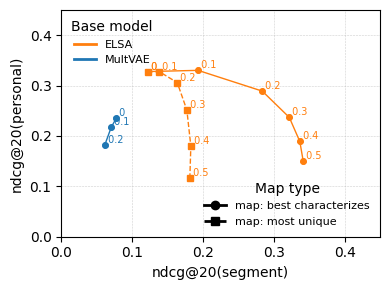

In [13]:
plot_results(data=results, metric_x="ndcg@20(segment)", metric_y="ndcg@20(personal)", path="results/figures/steering.png")